# SIT307 11.1HD - Machine Learning Research

## Reproduction of:
**An efficient stacking-based ensemble technique for early heart attack prediction**

### Part 1 - Reproduction of Published Machine Learning Results

This notebook reproduces and evaluates the machine learning methodology presented in the selected research paper. The study uses the Heart Disease dataset and compares six individual classification algorithms before combining them using a stacking-based ensemble approach.

The reproduction will follow the published methodology as closely as possible. Where implementation details are not clearly specified in the paper, reasonable and reproducible assumptions will be documented.

## 1. Environment Setup and Libraries

The required Python libraries are imported for data manipulation, preprocessing, machine learning, evaluation, and visualisation.

In [1]:
# Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Preprocessing and data splitting
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler

# Machine learning models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier
from sklearn.metrics import matthews_corrcoef
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.model_selection import GroupShuffleSplit
from sklearn.model_selection import StratifiedGroupKFold

# Evaluation metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve
)

print("Libraries imported successfully.")

Libraries imported successfully.


In [2]:
# Record package versions
import sklearn
import xgboost

print("NumPy version:", np.__version__)
print("Pandas version:", pd.__version__)
print("Scikit-learn version:", sklearn.__version__)
print("XGBoost version:", xgboost.__version__)

NumPy version: 2.5.2
Pandas version: 3.0.5
Scikit-learn version: 1.9.0
XGBoost version: 3.4.1


## 2. Dataset Loading and Verification

The Heart Disease dataset is loaded and inspected to verify that its structure, features, target variable, and value ranges are consistent with those described in the selected research paper.

In [3]:
# Load the dataset
import pandas as pd

df = pd.read_csv("../data/heart.csv")

print("Dataset loaded successfully.")
print("Dataset shape:", df.shape)

Dataset loaded successfully.
Dataset shape: (1025, 14)


In [4]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [5]:
print("Columns:")
print(df.columns.tolist())

Columns:
['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target']


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


In [7]:
# Missing values
missing_values = df.isnull().sum()

print("Missing values in each column:")
print(missing_values)

print("\nTotal missing values:", missing_values.sum())

Missing values in each column:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

Total missing values: 0


### Missing Values

The dataset was checked for missing values before preprocessing. No missing values were identified in any of the 14 attributes.

The selected paper describes a preprocessing stage for handling missing values using a regression-based imputation method. However, since the supplied dataset contains no missing observations, no imputation is required for this reproduction.

In [8]:
# Target distribution
target_counts = df["target"].value_counts().sort_index()
target_percentages = df["target"].value_counts(normalize=True).sort_index() * 100

target_distribution = pd.DataFrame({
    "Count": target_counts,
    "Percentage": target_percentages
})

target_distribution

,Count,Percentage
target,,
0,499,48.682927
1,526,51.317073


### Target Distribution

The target variable is relatively balanced. There are 499 observations representing no heart disease (`target = 0`) and 526 observations representing heart disease (`target = 1`).

Therefore, there is no major class imbalance in the supplied dataset.

In [9]:
# Duplicate rows
duplicate_count = df.duplicated().sum()
unique_count = len(df) - duplicate_count
duplicate_percentage = (duplicate_count / len(df)) * 100

print("Total rows:", len(df))
print("Unique rows:", unique_count)
print("Duplicate rows:", duplicate_count)
print(f"Duplicate percentage: {duplicate_percentage:.2f}%")

Total rows: 1025
Unique rows: 302
Duplicate rows: 723
Duplicate percentage: 70.54%


### Duplicate Observations

The dataset contains 723 exact duplicate rows, leaving 302 unique observations out of 1,025 total rows.

The paper reports using all 1,025 observations but does not clearly describe whether duplicate observations were identified or removed before model training. Therefore, the duplicates are retained at this stage to reproduce the published experiment as closely as possible.

The possible effect of duplicate observations on model evaluation will be investigated separately during the critical analysis.

In [10]:
# Check feature ranges
feature_ranges = pd.DataFrame({
    "Minimum": df.min(),
    "Maximum": df.max()
})

feature_ranges

,Minimum,Maximum
age,29.0,77.0
sex,0.0,1.0
cp,0.0,3.0
trestbps,94.0,200.0
chol,126.0,564.0
fbs,0.0,1.0
restecg,0.0,2.0
thalach,71.0,202.0
exang,0.0,1.0
oldpeak,0.0,6.2


### Comparison with the Published Dataset Description

The dataset closely matches the feature descriptions and value ranges reported in the paper. However, two minor diferences were observed:

- The paper describes `ca` as ranging from 0 to 3, while the supplied dataset contains values from 0 to 4.
- The paper describes `thal` as ranging from 1 to 3, while the supplied dataset contains values from 0 to 3.

These values were retained without modification because they are present in the source dataset used for the reproduction study.

### Dataset Verification Summary

The supplied dataset contains 1,025 observations, 13 predictor variables and one binary target variable, consistent with the overall dataset structure reported in the selected paper.

No missing values were identified, and the target classes are approximately balanced. A substantial number of exact duplicate rows were identified, which will be retained during the initial reproduction but examined later as a possible methodological limitation.

Overall, the dataset is suitable for proceeding with the reproduction of the published machine learning experiments.

## 3. Data Preprocessing

The preprocessing procedure follows the methodology described in the selected paper as closely as possible.

The dataset contains no missing values, so missing-value imputation is not required. The categorical features are already represented using numerical codes in the source dataset, so no additional categorical encoding is applied.

The paper states that numerical attributes are normalized but does not specify the exact normalisation method. Min-Max scaling is there fore used as a reasonable reproducible assumption for the continuous numerical features.

All 13 predictor variables are retained for the initial reproduction.

In [11]:
# Separate input features and target variable
X = df.drop("target", axis=1)
y = df["target"]

print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)

Feature matrix shape: (1025, 13)
Target shape: (1025,)


The target variable (`target`) was separated from the 13 predictor variables. A target value of 0 indicates no heart disease, while a value of 1 indicates the presence of heart disease.

In [12]:
# Identify continuous and categorical features
continuous_features = [
    "age",
    "trestbps",
    "chol",
    "thalach",
    "oldpeak"
]

categorical_features = [
    "sex",
    "cp",
    "fbs",
    "restecg",
    "exang",
    "slope",
    "ca",
    "thal"
]

print("Continuous features:", continuous_features)
print("Categorical/discrete features:", categorical_features)

Continuous features: ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']
Categorical/discrete features: ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal']


In [13]:
# 80/20 train-test split
# The paper does not report a random seed, therefore random_state=42
# is used to make this reproduction deterministic.

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

print("\nTraining target distribution:")
print(y_train.value_counts())

print("\nTesting target distribution:")
print(y_test.value_counts())

Training samples: 820
Testing samples: 205

Training target distribution:
target
1    423
0    397
Name: count, dtype: int64

Testing target distribution:
target
1    103
0    102
Name: count, dtype: int64


In [14]:
# Create copies so the original data remains unchanged
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

# Min-Max normalisation
scaler = MinMaxScaler()

X_train_scaled[continuous_features] = scaler.fit_transform(
    X_train[continuous_features]
)

X_test_scaled[continuous_features] = scaler.transform(
    X_test[continuous_features]
)

print("Preprocessing completed successfully.")

Preprocessing completed successfully.


In [15]:
X_train_scaled.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
835,0.416667,1,2,0.226415,0.052511,0,0,0.419847,0,0.129032,2,3,2
137,0.729167,0,0,0.811321,0.454338,0,1,0.633588,1,0.000000,2,0,2
534,0.520833,0,2,0.132075,0.321918,0,0,0.732824,0,0.000000,2,0,2
495,0.625000,1,0,0.386792,0.246575,0,1,0.687023,0,0.080645,1,0,3
244,0.458333,1,2,0.292453,0.271689,1,0,0.725191,0,0.387097,1,0,2


In [16]:
X_train_scaled[continuous_features].describe().loc[["min", "max"]]

,age,trestbps,chol,thalach,oldpeak
min,0.0,0.0,0.0,0.0,0.0
max,1.0,1.0,1.0,1.0,1.0


### Reproduction Assumptions

Several implemantation details are not explicitly specified in the published paper. The following assumptions were therefore made:

1. **Train/test split:** An 80/20 split was used because the reported confusion matrix contains 205 test observations from the 1,025-row dataset.
2. **Random seed:** The paper does not report a random seed. `random_state=42` was selected to make the experiment reproducible.
3. **Missing values:** No missing values are present in the supplied dataset, so imputation was not required.
4. **Categorical encoding:** The categorical variables are already numerically encoded in the source dataset; therefore, no additional encoding was applied.
5. **Normalisation:** The paper states that numerical features were normalised but does not specify the exact technique. Min-Max scaling was applied to continuous numerical features as a reproducible assumption.
6. **Duplicate observations:** Duplicate rows were retained during the initial reproduction because the paper reports using all 1,025 observations and does not state that duplicates were removed.
7. **Feature set:** All 13 predictor variables were retained because the paper does not clearly specify a reduced feature subset for the reported experiments.

## 4. Reproduction of Individual Classification Models

Six individual machine learning classifiers are reproduced following the selected paper:

- Logistic Regression
- Decision Tree
- Random Forest
- XGBoost
- Naive Bayes
- K-Nearest Neighbors

Each model is evaluated using Accuracy, Precision, Recall, F1-score, Specificity, Matthews Correlation Coefficient (MCC), and AUC.

The same training and testing sets are used for all classifiers to ensure a consistent comparison.

In [17]:
def evaluate_model(model_name, model, X_train, X_test, y_train, y_test):
    
    # Train model
    model.fit(X_train, y_train)
    
    # Predictions
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    
    # Confusion matrix values
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
    
    # Evaluation metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    specificity = tn / (tn + fp)
    mcc = matthews_corrcoef(y_test, y_pred)
    auc = roc_auc_score(y_test, y_prob)
    
    results = {
        "Model": model_name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1,
        "Specificity": specificity,
        "MCC": mcc,
        "AUC": auc
    }
    
    return results, y_pred, y_prob

A reusable evaluation function was created so that every classifier is trained and evaluated using the same procedure. This reduces repeated code and ensures that the calculated metrics are directly comparable across models.

In [18]:
model_results = []

### 4.1 Logistic Regression

Logistic Regression is the first baseline classifier reproduced from the paper. Since the paper does not provide detailed hyperparameter settings, the standard scikit-learn implementation is used with an increased maximum number of iterations to ensure convergence.

In [19]:
lr_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

lr_results, lr_pred, lr_prob = evaluate_model(
    "Logistic Regression",
    lr_model,
    X_train_scaled,
    X_test_scaled,
    y_train,
    y_test
)

model_results.append(lr_results)

pd.DataFrame([lr_results])

,Model,Accuracy,Precision,Recall,F1 Score,Specificity,MCC,AUC
0,Logistic Regression,0.8,0.762712,0.873786,0.81448,0.72549,0.606241,0.88578


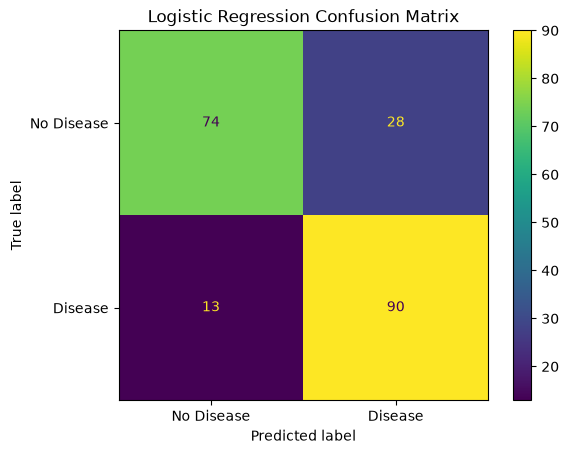

In [20]:
cm = confusion_matrix(y_test, lr_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No Disease", "Disease"]
)

disp.plot()
plt.title("Logistic Regression Confusion Matrix")
plt.show()

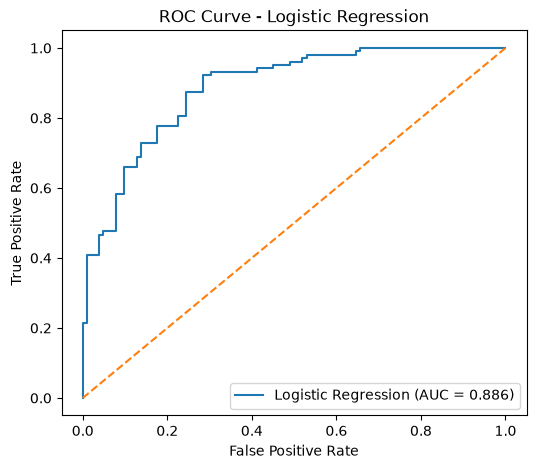

In [21]:
# ROC curve
fpr, tpr, _ = roc_curve(y_test, lr_prob)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"Logistic Regression (AUC = {lr_results['AUC']:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Logistic Regression")
plt.legend()
plt.show()

In [22]:
paper_lr_accuracy = 0.8439

print(f"Paper LR Accuracy:        {paper_lr_accuracy:.4f}")
print(f"Reproduced LR Accuracy:   {lr_results['Accuracy']:.4f}")
print(
    f"Difference:               "
    f"{lr_results['Accuracy'] - paper_lr_accuracy:+.4f}"
)

Paper LR Accuracy:        0.8439
Reproduced LR Accuracy:   0.8000
Difference:               -0.0439


#### Initial Comparison

The reproduced Logistic Regression performance is compared with the published accuracy of 84.39%. Any difference between the reproduced and published results may arise from implementation details that were not specified in the paper, such as the random train-test split, random seed, exact normalisation procedure, or classifier parameter settings.

The same experimental configuration will be maintained for the remaining classifiers to provide a consistent reproduction baseline.

### 4.2 Decision Tree

The Decision Tree classifier is reproduced as the second individual model. The paper does not provide the exact tree hyperparameter settings, so the standard scikit-learn Decision Tree classifier is used with a fixed random state for reproducibility.

In [23]:
dt_model = DecisionTreeClassifier(
    random_state=42
)

dt_results, dt_pred, dt_prob = evaluate_model(
    "Decision Tree",
    dt_model,
    X_train_scaled,
    X_test_scaled,
    y_train,
    y_test
)

model_results.append(dt_results)

pd.DataFrame([dt_results])

,Model,Accuracy,Precision,Recall,F1 Score,Specificity,MCC,AUC
0,Decision Tree,0.985366,1.0,0.970874,0.985222,1.0,0.971151,0.985437


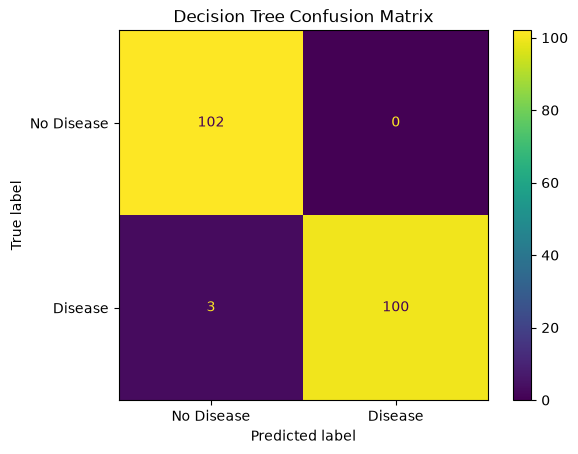

In [24]:
cm = confusion_matrix(y_test, dt_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No Disease", "Disease"]
)

disp.plot()
plt.title("Decision Tree Confusion Matrix")
plt.show()

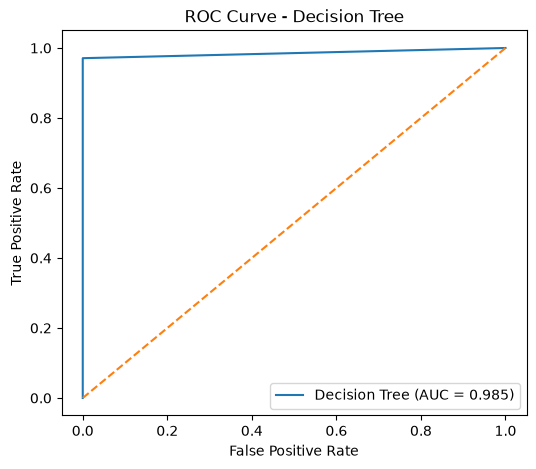

In [25]:
fpr, tpr, _ = roc_curve(y_test, dt_prob)

plt.figure(figsize=(6, 5))
plt.plot(
    fpr,
    tpr,
    label=f"Decision Tree (AUC = {dt_results['AUC']:.3f})"
)
plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Decision Tree")
plt.legend()
plt.show()

In [26]:
paper_dt_accuracy = 0.9268

print(f"Paper DT Accuracy:        {paper_dt_accuracy:.4f}")
print(f"Reproduced DT Accuracy:   {dt_results['Accuracy']:.4f}")
print(
    f"Difference:               "
    f"{dt_results['Accuracy'] - paper_dt_accuracy:+.4f}"
)

Paper DT Accuracy:        0.9268
Reproduced DT Accuracy:   0.9854
Difference:               +0.0586


#### Initial Comparison

The reproduced Decision Tree achieved an accuracy of **98.54%**, which is higher than the **92.68%** reported in the original paper. The model also achieved a precision and specificity of **1.00**, recall of **0.9709**, F1-score of **0.9852**, and AUC of **0.9854**.

The difference in performance may be caused by implementation details not fully specified in the paper, such as the train-test split, random seed, or Decision Tree parameters. The large number of duplicate observations in the dataset may also influence model performance, particularly for tree-based models. This will be investigated further during the critical analysis rather than altering the model to force agreement with the published result.

### 4.3 Random Forest

Random Forest is reproduced as the third individual classifier used in the paper. It combines multiple decision trees and aggregates their predictions to improve generalisation and reduce the tendency of a single Decision Tree to overfit.

The paper does not provide the exact Random Forest hyperparameter settings. Therefore, a standard Random Forest configuration is used with 100 trees and a fixed random state to ensure reproducibility.

In [27]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_results, rf_pred, rf_prob = evaluate_model(
    "Random Forest",
    rf_model,
    X_train_scaled,
    X_test_scaled,
    y_train,
    y_test
)

model_results.append(rf_results)

pd.DataFrame([rf_results])

,Model,Accuracy,Precision,Recall,F1 Score,Specificity,MCC,AUC
0,Random Forest,0.985366,1.0,0.970874,0.985222,1.0,0.971151,1.0


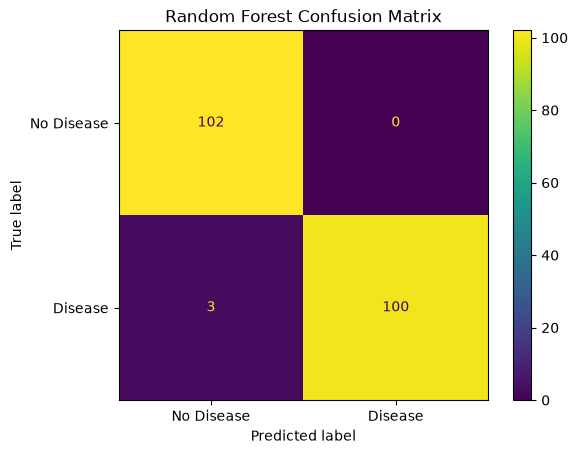

In [28]:
cm = confusion_matrix(y_test, rf_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No Disease", "Disease"]
)

disp.plot()
plt.title("Random Forest Confusion Matrix")
plt.show()

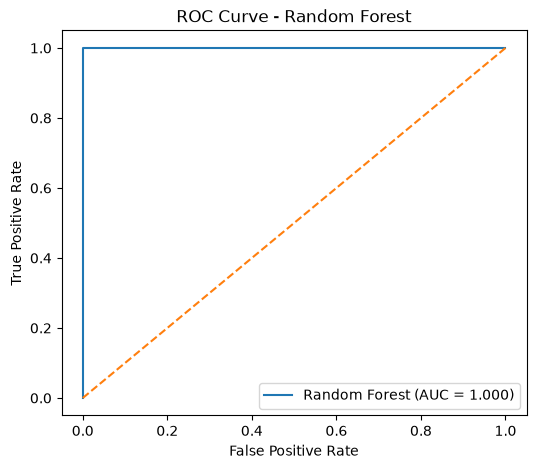

In [29]:
fpr, tpr, _ = roc_curve(y_test, rf_prob)

plt.figure(figsize=(6, 5))
plt.plot(
    fpr,
    tpr,
    label=f"Random Forest (AUC = {rf_results['AUC']:.3f})"
)
plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Random Forest")
plt.legend()
plt.show()

In [30]:
paper_rf_accuracy = 0.9268

print(f"Paper RF Accuracy:        {paper_rf_accuracy:.4f}")
print(f"Reproduced RF Accuracy:   {rf_results['Accuracy']:.4f}")
print(
    f"Difference:               "
    f"{rf_results['Accuracy'] - paper_rf_accuracy:+.4f}"
)

Paper RF Accuracy:        0.9268
Reproduced RF Accuracy:   0.9854
Difference:               +0.0586


#### Initial Comparison

The reproduced Random Forest achieved an accuracy of **98.54%**, compared with **92.68%** reported in the original paper. It achieved a precision and specificity of **1.00**, recall of **0.9709**, F1-score of **0.9852**, and an AUC of **1.00**.

The reproduced result is therefore higher than the published Random Forest performance. As with the Decision Tree, this difference may be influenced by unspecified implementation details such as the train-test split and model parameters. The high performance may also be affected by the substantial number of duplicate observations in the dataset. This potential effect will be examined later through controlled experiments rather than modifying the reproduction setup at this stage.

### 4.4 XGBoost

Extreme Gradient Boosting (XGBoost) is reproduced as the fourth individual classifier. XGBoost builds decision trees sequentially, with each new tree attempting to correct errors made by the previous models.

The paper does not report the exact XGBoost hyperparameter configuration. Therefore, a standard XGBoost classifier is used with a fixed random state to provide a reproducible baseline.

In [31]:
xgb_model = XGBClassifier(
    random_state=42,
    eval_metric="logloss"
)

xgb_results, xgb_pred, xgb_prob = evaluate_model(
    "XGBoost",
    xgb_model,
    X_train_scaled,
    X_test_scaled,
    y_train,
    y_test
)

model_results.append(xgb_results)

pd.DataFrame([xgb_results])

,Model,Accuracy,Precision,Recall,F1 Score,Specificity,MCC,AUC
0,XGBoost,0.985366,1.0,0.970874,0.985222,1.0,0.971151,0.989435


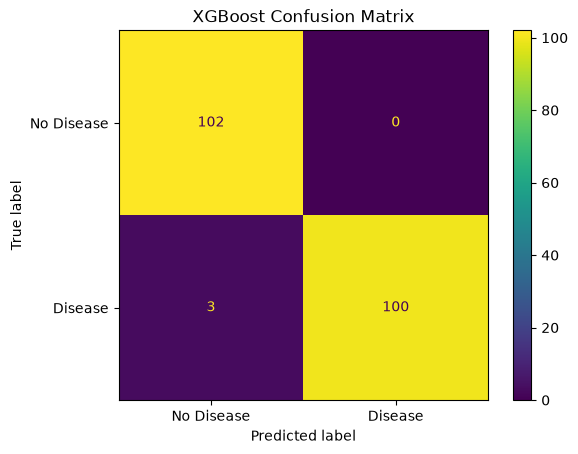

In [32]:
# Confusion matrix
cm = confusion_matrix(y_test, xgb_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No Disease", "Disease"]
)

disp.plot()
plt.title("XGBoost Confusion Matrix")
plt.show()

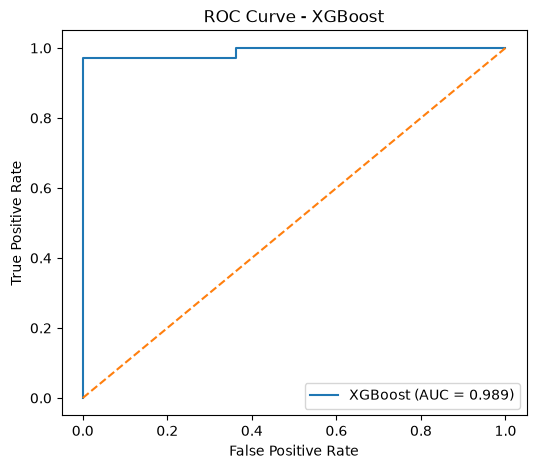

In [33]:
# ROC curve
fpr, tpr, _ = roc_curve(y_test, xgb_prob)

plt.figure(figsize=(6, 5))
plt.plot(
    fpr,
    tpr,
    label=f"XGBoost (AUC = {xgb_results['AUC']:.3f})"
)
plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - XGBoost")
plt.legend()
plt.show()

In [34]:
paper_xgb_accuracy = 0.9073

print(f"Paper XGB Accuracy:        {paper_xgb_accuracy:.4f}")
print(f"Reproduced XGB Accuracy:   {xgb_results['Accuracy']:.4f}")
print(
    f"Difference:                "
    f"{xgb_results['Accuracy'] - paper_xgb_accuracy:+.4f}"
)

Paper XGB Accuracy:        0.9073
Reproduced XGB Accuracy:   0.9854
Difference:                +0.0781


#### Initial Comparison

The reproduced XGBoost classifier achieved an accuracy of **98.54%**, which is higher than the **90.73%** reported in the original paper. The reproduced model also achieved a precision and specificity of **1.00**, recall of **0.9709**, F1-score of **0.9852**, and AUC of **0.9894**.

The difference in performance may be influenced by implementation details that are not fully specified in the paper, including the train-test split, random seed, and XGBoost hyperparameters. Similar to the tree-based models reproduced previously, the large number of duplicate observations in the dataset may also contribute to the high test performance. This possibility will be investigated later using controlled experiments.

### 4.5 Naive Bayes

Gaussian Naive Bayes is reproduced as the fifth individual classifier. Naive Bayes is a probabilistic classification method based on Bayes' theorem and assumes that the predictor variables are conditionally independent given the target class.

The paper does not report specific Naive Bayes parameter settings. Therefore, the standard Gaussian Naive Bayes implementation is used for the reproduction.

In [35]:
nb_model = GaussianNB()

nb_results, nb_pred, nb_prob = evaluate_model(
    "Naive Bayes",
    nb_model,
    X_train_scaled,
    X_test_scaled,
    y_train,
    y_test
)

model_results.append(nb_results)

pd.DataFrame([nb_results])

,Model,Accuracy,Precision,Recall,F1 Score,Specificity,MCC,AUC
0,Naive Bayes,0.8,0.754098,0.893204,0.817778,0.705882,0.610224,0.87055


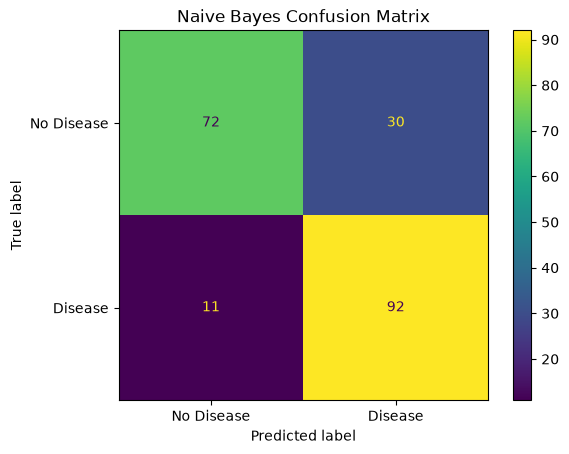

In [36]:
# Confusion matrix
cm = confusion_matrix(y_test, nb_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No Disease", "Disease"]
)

disp.plot()
plt.title("Naive Bayes Confusion Matrix")
plt.show()

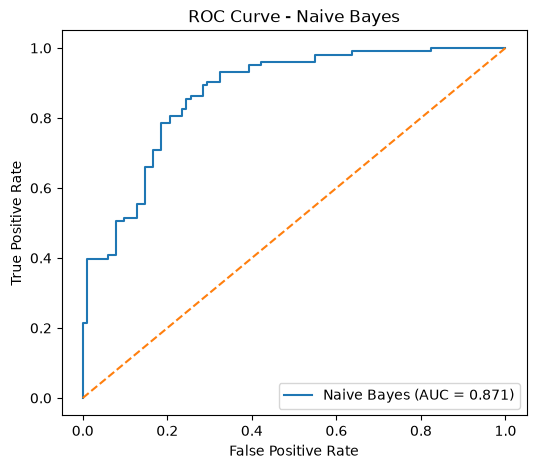

In [37]:
# ROC curve
fpr, tpr, _ = roc_curve(y_test, nb_prob)

plt.figure(figsize=(6, 5))
plt.plot(
    fpr,
    tpr,
    label=f"Naive Bayes (AUC = {nb_results['AUC']:.3f})"
)
plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Naive Bayes")
plt.legend()
plt.show()

In [38]:
paper_nb_accuracy = 0.8439

print(f"Paper NB Accuracy:        {paper_nb_accuracy:.4f}")
print(f"Reproduced NB Accuracy:   {nb_results['Accuracy']:.4f}")
print(
    f"Difference:               "
    f"{nb_results['Accuracy'] - paper_nb_accuracy:+.4f}"
)

Paper NB Accuracy:        0.8439
Reproduced NB Accuracy:   0.8000
Difference:               -0.0439


#### Initial Comparison

The reproduced Naive Bayes classifier achieved an accuracy of **80.00%**, compared with **84.39%** reported in the original paper. The reproduced model achieved a precision of **0.7541**, recall of **0.8932**, F1-score of **0.8178**, specificity of **0.7059**, and AUC of **0.8706**.

The reproduced result is moderately lower than the published Naive Bayes performance. This difference may be caused by implemantation details that are not fully specified in the paper, including the train-test split, random seed, and preprocessing procedure. Unlike the tree-based models, Naive Bayes does not appear to benefit as strongly from the duplicate observations in this particular test configuration.

### 4.6 K-Nearest Neighbors

K-Nearest Neighbors (KNN) is reproduced as the sixth individual classifier. KNN classifies each observation based on the classes of the nearest observations in the feature space and is therefore sensitive to differences in feature scale.

The continuous numerical features were normalised before training. Since the paper does not report the exact value of K or other KNN parameter settings, the standard scikit-learn configuration is used for the initial reproduction.

In [39]:
knn_model = KNeighborsClassifier()

knn_results, knn_pred, knn_prob = evaluate_model(
    "K-Nearest Neighbors",
    knn_model,
    X_train_scaled,
    X_test_scaled,
    y_train,
    y_test
)

model_results.append(knn_results)

pd.DataFrame([knn_results])

,Model,Accuracy,Precision,Recall,F1 Score,Specificity,MCC,AUC
0,K-Nearest Neighbors,0.858537,0.842593,0.883495,0.862559,0.833333,0.717854,0.962783


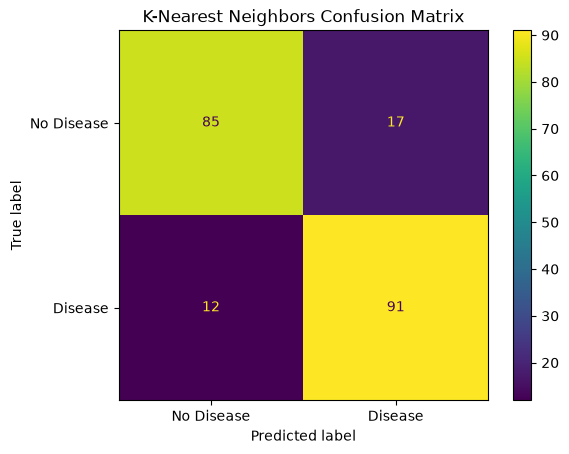

In [40]:
# confusion matrix
cm = confusion_matrix(y_test, knn_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No Disease", "Disease"]
)

disp.plot()
plt.title("K-Nearest Neighbors Confusion Matrix")
plt.show()

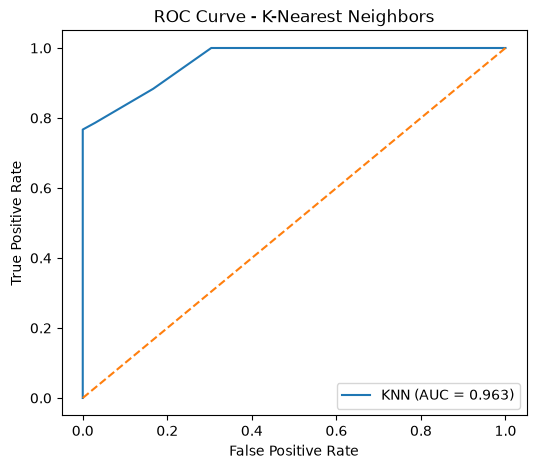

In [41]:
# ROC curve
fpr, tpr, _ = roc_curve(y_test, knn_prob)

plt.figure(figsize=(6, 5))
plt.plot(
    fpr,
    tpr,
    label=f"KNN (AUC = {knn_results['AUC']:.3f})"
)
plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - K-Nearest Neighbors")
plt.legend()
plt.show()

In [42]:
paper_knn_accuracy = 0.8585

print(f"Paper KNN Accuracy:        {paper_knn_accuracy:.4f}")
print(f"Reproduced KNN Accuracy:   {knn_results['Accuracy']:.4f}")
print(
    f"Difference:                "
    f"{knn_results['Accuracy'] - paper_knn_accuracy:+.4f}"
)

Paper KNN Accuracy:        0.8585
Reproduced KNN Accuracy:   0.8585
Difference:                +0.0000


#### Initial Comparison

The reproduced K-Nearest Neighbors classifier achieved an accuracy of **85.85%**, which closely matches the **85.85%** accuracy reported in the original paper. The reproduced model achived a precision of **0.8426**, recall of **0.8835**, F1-score of **0.8626**, specificity of **0.8333**, and AUC of **0.9628**.

Although the overall accuracy is almost identical to the published result, small differences remain in the other evaluation metrics. These differences may result from the unspecified train-test split, random seed, preprocessing details, or KNN configuration used by the original authors. Overall, KNN provides the closest reproduction of th published individual classifier results so far.

### 4.7 Comparison of Individual Classifiers

The reproduced results of all six individual classifiers are compared with the accuracy values reported in the original paper. This provides an overal view of how closely the reproduction matches the published experiments before implementing the proposed stacking ensemble.

In [43]:
# Combine reproduced model results
reproduced_results = pd.DataFrame(model_results)

reproduced_results.round(4)

,Model,Accuracy,Precision,Recall,F1 Score,Specificity,MCC,AUC
0,Logistic Regression,0.8000,0.7627,0.8738,0.8145,0.7255,0.6062,0.8858
1,Decision Tree,0.9854,1.0000,0.9709,0.9852,1.0000,0.9712,0.9854
2,Random Forest,0.9854,1.0000,0.9709,0.9852,1.0000,0.9712,1.0000
3,XGBoost,0.9854,1.0000,0.9709,0.9852,1.0000,0.9712,0.9894
4,Naive Bayes,0.8000,0.7541,0.8932,0.8178,0.7059,0.6102,0.8706
5,K-Nearest Neighbors,0.8585,0.8426,0.8835,0.8626,0.8333,0.7179,0.9628


In [44]:
paper_accuracies = {
    "Logistic Regression": 0.8439,
    "Decision Tree": 0.9268,
    "Random Forest": 0.9268,
    "XGBoost": 0.9073,
    "Naive Bayes": 0.8439,
    "K-Nearest Neighbors": 0.8585
}

accuracy_comparison = reproduced_results[
    ["Model", "Accuracy"]
].copy()

accuracy_comparison["Paper Accuracy"] = accuracy_comparison["Model"].map(
    paper_accuracies
)

accuracy_comparison["Difference"] = (
    accuracy_comparison["Accuracy"]
    - accuracy_comparison["Paper Accuracy"]
)

accuracy_comparison = accuracy_comparison.rename(
    columns={"Accuracy": "Reproduced Accuracy"}
)

accuracy_comparison.round(4)

,Model,Reproduced Accuracy,Paper Accuracy,Difference
0,Logistic Regression,0.8000,0.8439,-0.0439
1,Decision Tree,0.9854,0.9268,0.0586
2,Random Forest,0.9854,0.9268,0.0586
3,XGBoost,0.9854,0.9073,0.0781
4,Naive Bayes,0.8000,0.8439,-0.0439
5,K-Nearest Neighbors,0.8585,0.8585,0.0000


#### Individual Model Comparison

The reproduction produced mixed agreement with the published results. KNN reproduced the published accuracy almost exactly, while Logistic Regression and Naive Bayes produced moderately lower accuracies. In contrast, Decision Tree, Random Forest, and XGBoost achieved substantially higher accuracies than those reported in the paper.

The particulaly strong performance of the tree-based models suggests that characteristics of the dataset and experimental split may have an important influence on the results. Since the dataset contains a large number of duplicate observations, this issue will be examined in the later critical analysis rather than changing the reproduction procedure at this stage.

## 5. Reproduction of the 5-Fold Stacking Ensemble

The main proposed method in the selected paper is a stacking-based ensemble that combines the six individual classifiers used previously.

The base learners are:

- Logistic Regression
- Decision Tree
- Random Forest
- XGBoost
- Naive Bayes
- K-Nearest Neighbors

The paper states that a 5-fold stacking procedure is used, where predictions from the base classifiers are combined by a meta-classifier.

However, the exact meta-classifier and its parameter settings are not clearly specified. Therefore, Logistic Regression is used as the meta-classifier as a reasonable and reproducible assumption. The same preprocessing and train-test split used for the individual classifiers are retained.

In [45]:
# Define the six base learners
base_estimators = [
    ("lr", LogisticRegression(
        max_iter=1000,
        random_state=42
    )),
    
    ("dt", DecisionTreeClassifier(
        random_state=42
    )),
    
    ("rf", RandomForestClassifier(
        n_estimators=100,
        random_state=42
    )),
    
    ("xgb", XGBClassifier(
        random_state=42,
        eval_metric="logloss"
    )),
    
    ("nb", GaussianNB()),
    
    ("knn", KNeighborsClassifier())
]

In [46]:
# Construct the stacking classifier
stacking_model = StackingClassifier(
    estimators=base_estimators,
    final_estimator=LogisticRegression(
        max_iter=1000,
        random_state=42
    ),
    cv=5,
    stack_method="predict_proba"
)

print(stacking_model)

StackingClassifier(cv=5,
                   estimators=[('lr',
                                LogisticRegression(max_iter=1000,
                                                   random_state=42)),
                               ('dt', DecisionTreeClassifier(random_state=42)),
                               ('rf', RandomForestClassifier(random_state=42)),
                               ('xgb',
                                XGBClassifier(base_score=None, booster=None,
                                              callbacks=None,
                                              colsample_bylevel=None,
                                              colsample_bynode=None,
                                              colsample_bytree=None,
                                              device=None,
                                              early_stopping_roun...
                                              max_cat_to_onehot=None,
                                              max_delta_s

In [47]:
# Train and evaluate the stacking model
stack_results, stack_pred, stack_prob = evaluate_model(
    "Stacking Ensemble",
    stacking_model,
    X_train_scaled,
    X_test_scaled,
    y_train,
    y_test
)

pd.DataFrame([stack_results])

,Model,Accuracy,Precision,Recall,F1 Score,Specificity,MCC,AUC
0,Stacking Ensemble,0.985366,1.0,0.970874,0.985222,1.0,0.971151,1.0


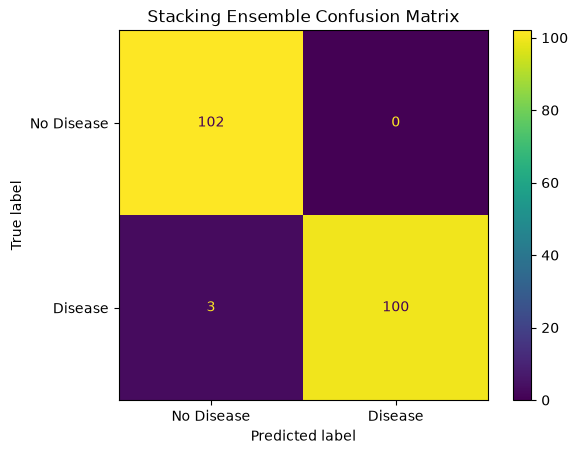

In [48]:
# Confusion Matrix
cm = confusion_matrix(y_test, stack_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No Disease", "Disease"]
)

disp.plot()
plt.title("Stacking Ensemble Confusion Matrix")
plt.show()

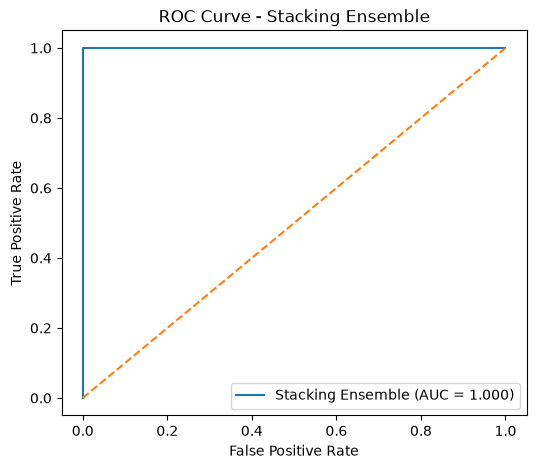

In [49]:
# ROC Curve
fpr, tpr, _ = roc_curve(y_test, stack_prob)

plt.figure(figsize=(6, 5))

plt.plot(
    fpr,
    tpr,
    label=f"Stacking Ensemble (AUC = {stack_results['AUC']:.3f})"
)

plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Stacking Ensemble")
plt.legend()
plt.show()

In [50]:
# Compare with the published result
paper_stack_accuracy = 0.9853

print(f"Paper Stacking Accuracy:       {paper_stack_accuracy:.4f}")
print(f"Reproduced Stacking Accuracy:  {stack_results['Accuracy']:.4f}")
print(
    f"Difference:                    "
    f"{stack_results['Accuracy'] - paper_stack_accuracy:+.4f}"
)

Paper Stacking Accuracy:       0.9853
Reproduced Stacking Accuracy:  0.9854
Difference:                    +0.0001


In [51]:
stack_comparison = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "AUC"
    ],
    
    "Paper": [
        0.9853,
        1.0000,
        0.9727,
        0.9861,
        0.9880
    ],
    
    "Reproduced": [
        stack_results["Accuracy"],
        stack_results["Precision"],
        stack_results["Recall"],
        stack_results["F1 Score"],
        stack_results["AUC"]
    ]
})

stack_comparison["Difference"] = (
    stack_comparison["Reproduced"]
    - stack_comparison["Paper"]
)

stack_comparison.round(4)

,Metric,Paper,Reproduced,Difference
0,Accuracy,0.9853,0.9854,0.0001
1,Precision,1.0000,1.0000,0.0000
2,Recall,0.9727,0.9709,-0.0018
3,F1 Score,0.9861,0.9852,-0.0009
4,AUC,0.9880,1.0000,0.0120


### 5.1 Stacking Ensemble Results and Comparison

The reproduced 5-fold stacking ensemble achieved an accuracy of **98.54%**, which is almost identical to the **98.53%** reported in the original paper. The reproduced model also achieved a precision of **1.0000**, recall of **0.9709**, F1-score of **0.9852**, specificity of **1.0000**, and AUC of **1.0000**.

The reproduced accuracy differs from the published result by only **0.01 percentage points**. Both experiments correctly classify 202 out of 205 test observations. However, the confusion matrices indicate that the test samples are not identical. The published experiment contains 95 negative and 110 positive test observations, whereas the reproduced split contains 102 negative and 103 positive observations.

Therefore, the very close overall accuracy demonstrates that the main reported stacking performance can be reproduced under the current experimental configuration, although differences in class distribution, individual classifier performance, preprocessing assumptions, and unspecified model parameters remain.

The particularly high performance should also be interpreted cautiously because the dataset contains a substantial number of duplicate observations. The possible influence of these duplicates on model generalisation will be investigated in the following critical analysis.

## 6. Critical Analysis of the Reproduced Results

Although the reproduced stacking ensemble closely matched the accuracy reported in the original paper, additional analysis is requried to determine whether the observed performance is robust.

During dataset verification, 723 exact duplicate rows were identified among the 1,025 observations. This leaves only 302 unique observations. If identical observations occur in both the training and testing sets, the evaluation may provide an optimistic estimate of performance because the model can be tested on records identical to those already present during training.

The following experiment therefore investigate the effect of exact duplicate observations while keeping the remaining experimental settings as consistent as possible with the initial reproduction.

### 6.1 Train-Test Duplicate Overlap

Before removing duplicate observations, the original 80/20 split is examined to determine how many test observations have an exact duplicate in the training set.

In [52]:
# Combine predictors and target for the existing training and testing sets
train_full = X_train.copy()
train_full["target"] = y_train

test_full = X_test.copy()
test_full["target"] = y_test

# Convert each training row to a tuple for exact comparison
train_rows = set(map(tuple, train_full.to_numpy()))

# Check whether each test observation has an identical row in training data
test_overlap = [
    tuple(row) in train_rows
    for row in test_full.to_numpy()
]

overlap_count = sum(test_overlap)
overlap_percentage = (overlap_count / len(test_full)) * 100

print("Test observations:", len(test_full))
print("Test observations duplicated in training:", overlap_count)
print(f"Percentage of test set duplicated in training: {overlap_percentage:.2f}%")

Test observations: 205
Test observations duplicated in training: 199
Percentage of test set duplicated in training: 97.07%


### 6.2 Deduplicated Dataset Experiment

To investigate the effect of duplicate observations, a second experiment is performed after removing exact duplicate rows.

The original reproduction results are preserved unchanged. The deduplicated experiment uses the same 80/20 train-test proportion, random seed, preprocessing procedure, classifier configurations, and evaluation metrics. Therefore, the main experimental change is the removal of exact duplicate observations.

In [53]:
# Remove exact duplicate observations
df_dedup = df.drop_duplicates().reset_index(drop=True)

print("Original dataset size:", df.shape)
print("Deduplicated dataset size:", df_dedup.shape)
print("Rows removed:", len(df) - len(df_dedup))

Original dataset size: (1025, 14)
Deduplicated dataset size: (302, 14)
Rows removed: 723


In [54]:
# Prepare the deduplicated data
# Separate predictors and target
X_dedup = df_dedup.drop("target", axis=1)
y_dedup = df_dedup["target"]

# Use the same 80/20 split and random seed as the reproduction
X_train_dedup, X_test_dedup, y_train_dedup, y_test_dedup = train_test_split(
    X_dedup,
    y_dedup,
    test_size=0.20,
    random_state=42
)

print("Deduplicated training samples:", len(X_train_dedup))
print("Deduplicated testing samples:", len(X_test_dedup))

print("\nTraining target distribution:")
print(y_train_dedup.value_counts())

print("\nTesting target distribution:")
print(y_test_dedup.value_counts())

Deduplicated training samples: 241
Deduplicated testing samples: 61

Training target distribution:
target
1    135
0    106
Name: count, dtype: int64

Testing target distribution:
target
0    32
1    29
Name: count, dtype: int64


In [55]:
# Apply the same preprocessing
# Create copies
X_train_dedup_scaled = X_train_dedup.copy()
X_test_dedup_scaled = X_test_dedup.copy()

# Fit scaler using training data only
dedup_scaler = MinMaxScaler()

X_train_dedup_scaled[continuous_features] = dedup_scaler.fit_transform(
    X_train_dedup[continuous_features]
)

X_test_dedup_scaled[continuous_features] = dedup_scaler.transform(
    X_test_dedup[continuous_features]
)

print("Deduplicated dataset preprocessing completed successfully.")

Deduplicated dataset preprocessing completed successfully.


In [56]:
# Re-run all six classifiers
dedup_models = [
    (
        "Logistic Regression",
        LogisticRegression(
            max_iter=1000,
            random_state=42
        )
    ),
    (
        "Decision Tree",
        DecisionTreeClassifier(
            random_state=42
        )
    ),
    (
        "Random Forest",
        RandomForestClassifier(
            n_estimators=100,
            random_state=42
        )
    ),
    (
        "XGBoost",
        XGBClassifier(
            random_state=42,
            eval_metric="logloss"
        )
    ),
    (
        "Naive Bayes",
        GaussianNB()
    ),
    (
        "K-Nearest Neighbors",
        KNeighborsClassifier()
    )
]

dedup_results = []

for model_name, model in dedup_models:
    
    results, predictions, probabilities = evaluate_model(
        model_name,
        model,
        X_train_dedup_scaled,
        X_test_dedup_scaled,
        y_train_dedup,
        y_test_dedup
    )
    
    dedup_results.append(results)

dedup_results_df = pd.DataFrame(dedup_results)

dedup_results_df.round(4)

,Model,Accuracy,Precision,Recall,F1 Score,Specificity,MCC,AUC
0,Logistic Regression,0.7869,0.7353,0.8621,0.7937,0.7188,0.5840,0.8675
1,Decision Tree,0.7377,0.7407,0.6897,0.7143,0.7812,0.4735,0.7355
2,Random Forest,0.8361,0.7879,0.8966,0.8387,0.7812,0.6793,0.8772
3,XGBoost,0.8033,0.7576,0.8621,0.8065,0.7500,0.6134,0.8524
4,Naive Bayes,0.8525,0.8333,0.8621,0.8475,0.8438,0.7051,0.8556
5,K-Nearest Neighbors,0.8361,0.7714,0.9310,0.8438,0.7500,0.6877,0.8901


In [57]:
# Re-run the stacking ensemble
dedup_base_estimators = [
    (
        "lr",
        LogisticRegression(
            max_iter=1000,
            random_state=42
        )
    ),
    (
        "dt",
        DecisionTreeClassifier(
            random_state=42
        )
    ),
    (
        "rf",
        RandomForestClassifier(
            n_estimators=100,
            random_state=42
        )
    ),
    (
        "xgb",
        XGBClassifier(
            random_state=42,
            eval_metric="logloss"
        )
    ),
    (
        "nb",
        GaussianNB()
    ),
    (
        "knn",
        KNeighborsClassifier()
    )
]

dedup_stacking_model = StackingClassifier(
    estimators=dedup_base_estimators,
    final_estimator=LogisticRegression(
        max_iter=1000,
        random_state=42
    ),
    cv=5,
    stack_method="predict_proba"
)

dedup_stack_results, dedup_stack_pred, dedup_stack_prob = evaluate_model(
    "Stacking Ensemble",
    dedup_stacking_model,
    X_train_dedup_scaled,
    X_test_dedup_scaled,
    y_train_dedup,
    y_test_dedup
)

pd.DataFrame([dedup_stack_results]).round(4)

,Model,Accuracy,Precision,Recall,F1 Score,Specificity,MCC,AUC
0,Stacking Ensemble,0.8361,0.7714,0.931,0.8438,0.75,0.6877,0.8976


In [58]:
dedup_results.append(dedup_stack_results)

dedup_results_df = pd.DataFrame(dedup_results)

dedup_results_df.round(4)

,Model,Accuracy,Precision,Recall,F1 Score,Specificity,MCC,AUC
0,Logistic Regression,0.7869,0.7353,0.8621,0.7937,0.7188,0.5840,0.8675
1,Decision Tree,0.7377,0.7407,0.6897,0.7143,0.7812,0.4735,0.7355
2,Random Forest,0.8361,0.7879,0.8966,0.8387,0.7812,0.6793,0.8772
3,XGBoost,0.8033,0.7576,0.8621,0.8065,0.7500,0.6134,0.8524
4,Naive Bayes,0.8525,0.8333,0.8621,0.8475,0.8438,0.7051,0.8556
5,K-Nearest Neighbors,0.8361,0.7714,0.9310,0.8438,0.7500,0.6877,0.8901
6,Stacking Ensemble,0.8361,0.7714,0.9310,0.8438,0.7500,0.6877,0.8976


In [59]:
# Add the original stacking result to the original model results
original_all_results = pd.concat(
    [
        reproduced_results,
        pd.DataFrame([stack_results])
    ],
    ignore_index=True
)

duplicate_comparison = original_all_results[
    ["Model", "Accuracy", "AUC"]
].merge(
    dedup_results_df[
        ["Model", "Accuracy", "AUC"]
    ],
    on="Model",
    suffixes=("_Original", "_Deduplicated")
)

duplicate_comparison["Accuracy Change"] = (
    duplicate_comparison["Accuracy_Deduplicated"]
    - duplicate_comparison["Accuracy_Original"]
)

duplicate_comparison["AUC Change"] = (
    duplicate_comparison["AUC_Deduplicated"]
    - duplicate_comparison["AUC_Original"]
)

duplicate_comparison.round(4)

,Model,Accuracy_Original,AUC_Original,Accuracy_Deduplicated,AUC_Deduplicated,Accuracy Change,AUC Change
0,Logistic Regression,0.8000,0.8858,0.7869,0.8675,-0.0131,-0.0183
1,Decision Tree,0.9854,0.9854,0.7377,0.7355,-0.2477,-0.2500
2,Random Forest,0.9854,1.0000,0.8361,0.8772,-0.1493,-0.1228
3,XGBoost,0.9854,0.9894,0.8033,0.8524,-0.1821,-0.1371
4,Naive Bayes,0.8000,0.8706,0.8525,0.8556,0.0525,-0.0149
5,K-Nearest Neighbors,0.8585,0.9628,0.8361,0.8901,-0.0225,-0.0727
6,Stacking Ensemble,0.9854,1.0000,0.8361,0.8976,-0.1493,-0.1024


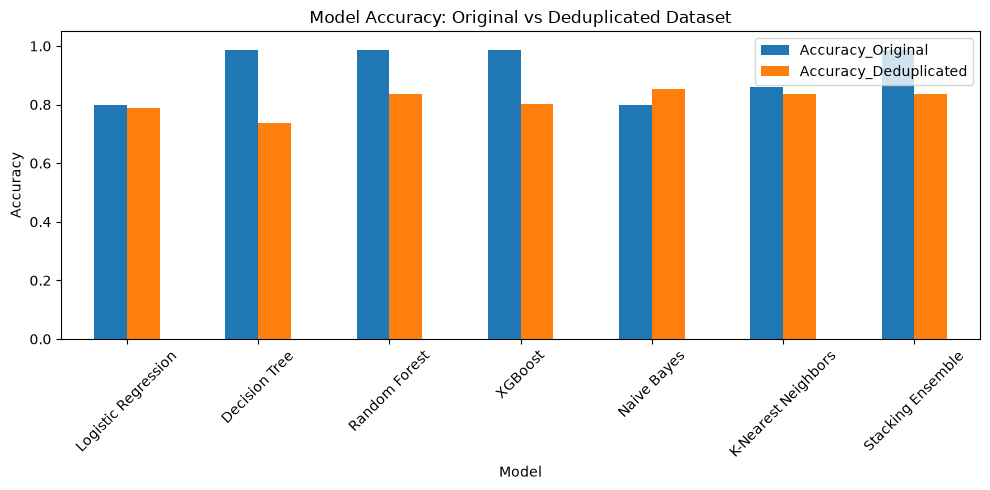

In [60]:
accuracy_plot_data = duplicate_comparison.set_index("Model")[
    ["Accuracy_Original", "Accuracy_Deduplicated"]
]

accuracy_plot_data.plot(
    kind="bar",
    figsize=(10, 5)
)

plt.ylabel("Accuracy")
plt.xlabel("Model")
plt.title("Model Accuracy: Original vs Deduplicated Dataset")
plt.xticks(rotation=45)
plt.ylim(0, 1.05)
plt.tight_layout()
plt.show()

### 6.3 Analysis of Duplicate Observation Effects

The duplicate-overlap analysis revealed that **199 of the 205 test observations (97.07%)** in the original reproduction had an exact duplicate present in the training set. This indicates substantial train-test contamination caused by repeated observations.

When exact duplicate rows were removed, the dataset was reduced from 1,025 observations to 302 unique observations. The same model configurtions, preprocessing procedure, train-test ratio, and random seed were then applied to the deduplicated dataset.

A substantial reduction in performance was observed for several models. Decision Tree accuracy decreased from **98.54% to 73.77%**, Random Forest decreased from **98.54% to 83.61%**, and XGBoost decreased from **98.54% to 80.33%**. The stacking ensemble also decreased from **98.54% to 83.61%**, while its AUC decreased from **1.0000 to 0.8976**.

These results suggest that the extremely high performance obtained using the original 1,025-row dataset is strongly associated with the presence of repeated observations across the training and testing sets. Tree-based models appear particularly sensitive to this issue because they can closely reproduce decision rules associated with observations that are repeated in both sets.

However, duplicate removal also reduces the training dataset from 820 observations in the original experiment to only 241 observations. Therefore, the observed reduction in performance cannot be atributed exclusively to duplicate overlap. Both the removal of train-test duplication and the smaller effective training sample may contribute to the change in performance.

Overall, the experiment raises concerns about whether the reported 98.53% stacking accuracy represents performance on genuinely unseen patient patterns. A more robust validation strategy is therefore required before drawing conclusions about the generalisation ability of the ensemble model.

### 6.4 Group-Aware Validation Experiment

The deduplicated experiment substantially reduces the dataset size, so some of the observed performance reduction may result from having fewer training observations rather than duplicate removal alone.

To investigate this further, a group-aware validation experiment is performed on the original 1,025-row dataset. Identical predictor records are assigned to the same group, ensuring that copies of the same feature vector cannot appear in both the training and testing sets.

A 5-fold StratifiedGroupKFold split is used and one fold is selected as the held-out test set. This produces an approximately 80/20 split while also preserving the class distribution as closely as possible. Unlike the deduplicated experiment, all 1,025 observations are retained.

In [61]:
# Assign identical predictor rows to the same group
groups = pd.Series(
    pd.factorize(pd.MultiIndex.from_frame(X))[0],
    index=X.index,
    name="duplicate_group"
)

print("Total observations:", len(X))
print("Unique feature groups:", groups.nunique())

# Check whether identical predictor records have conflicting target labels
feature_columns = X.columns.tolist()

conflicting_groups = (
    df.groupby(feature_columns)["target"]
      .nunique()
      .gt(1)
      .sum()
)

print("Feature groups with conflicting target labels:", conflicting_groups)

Total observations: 1025
Unique feature groups: 302
Feature groups with conflicting target labels: 0


In [62]:
# Create a stratified group-aware approximately 80/20 split
group_split = StratifiedGroupKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

train_idx, test_idx = next(
    group_split.split(X, y, groups=groups)
)

X_train_group = X.iloc[train_idx].copy()
X_test_group = X.iloc[test_idx].copy()

y_train_group = y.iloc[train_idx].copy()
y_test_group = y.iloc[test_idx].copy()

print("Training observations:", len(X_train_group))
print("Testing observations:", len(X_test_group))

print("\nTraining target distribution:")
print(y_train_group.value_counts())

print("\nTesting target distribution:")
print(y_test_group.value_counts())

Training observations: 818
Testing observations: 207

Training target distribution:
target
1    420
0    398
Name: count, dtype: int64

Testing target distribution:
target
1    106
0    101
Name: count, dtype: int64


In [63]:
train_groups = set(groups.iloc[train_idx])
test_groups = set(groups.iloc[test_idx])

overlapping_groups = train_groups.intersection(test_groups)

print("Unique groups in training:", len(train_groups))
print("Unique groups in testing:", len(test_groups))
print("Groups shared between training and testing:", len(overlapping_groups))

Unique groups in training: 242
Unique groups in testing: 60
Groups shared between training and testing: 0


In [64]:
train_group_rows = set(
    map(tuple, X_train_group.to_numpy())
)

group_overlap = sum(
    tuple(row) in train_group_rows
    for row in X_test_group.to_numpy()
)

print(
    "Test observations with identical features in training:",
    group_overlap
)

Test observations with identical features in training: 0


In [65]:
X_train_group_scaled = X_train_group.copy()
X_test_group_scaled = X_test_group.copy()

group_scaler = MinMaxScaler()

X_train_group_scaled[continuous_features] = group_scaler.fit_transform(
    X_train_group[continuous_features]
)

X_test_group_scaled[continuous_features] = group_scaler.transform(
    X_test_group[continuous_features]
)

print("Group-aware preprocessing completed.")

print("X_train:", X_train_group_scaled.shape)
print("y_train:", y_train_group.shape)

print("X_test:", X_test_group_scaled.shape)
print("y_test:", y_test_group.shape)

Group-aware preprocessing completed.
X_train: (818, 13)
y_train: (818,)
X_test: (207, 13)
y_test: (207,)


In [66]:
group_models = [
    (
        "Logistic Regression",
        LogisticRegression(
            max_iter=1000,
            random_state=42
        )
    ),
    (
        "Decision Tree",
        DecisionTreeClassifier(
            random_state=42
        )
    ),
    (
        "Random Forest",
        RandomForestClassifier(
            n_estimators=100,
            random_state=42
        )
    ),
    (
        "XGBoost",
        XGBClassifier(
            random_state=42,
            eval_metric="logloss"
        )
    ),
    (
        "Naive Bayes",
        GaussianNB()
    ),
    (
        "K-Nearest Neighbors",
        KNeighborsClassifier()
    )
]

group_results = []

for model_name, model in group_models:

    results, predictions, probabilities = evaluate_model(
        model_name,
        model,
        X_train_group_scaled,
        X_test_group_scaled,
        y_train_group,
        y_test_group
    )

    group_results.append(results)

group_results_df = pd.DataFrame(group_results)

group_results_df.round(4)

,Model,Accuracy,Precision,Recall,F1 Score,Specificity,MCC,AUC
0,Logistic Regression,0.8599,0.8407,0.8962,0.8676,0.8218,0.7208,0.9588
1,Decision Tree,0.8164,0.7833,0.8868,0.8319,0.7426,0.6373,0.8147
2,Random Forest,0.8647,0.8197,0.9434,0.8772,0.7822,0.7372,0.9642
3,XGBoost,0.8647,0.8362,0.9151,0.8739,0.8119,0.7321,0.9503
4,Naive Bayes,0.8406,0.8349,0.8585,0.8465,0.8218,0.6810,0.9202
5,K-Nearest Neighbors,0.8213,0.8053,0.8585,0.8311,0.7822,0.6432,0.8810


In [67]:
group_base_estimators = [
    (
        "lr",
        LogisticRegression(
            max_iter=1000,
            random_state=42
        )
    ),
    (
        "dt",
        DecisionTreeClassifier(
            random_state=42
        )
    ),
    (
        "rf",
        RandomForestClassifier(
            n_estimators=100,
            random_state=42
        )
    ),
    (
        "xgb",
        XGBClassifier(
            random_state=42,
            eval_metric="logloss"
        )
    ),
    (
        "nb",
        GaussianNB()
    ),
    (
        "knn",
        KNeighborsClassifier()
    )
]

group_stacking_model = StackingClassifier(
    estimators=group_base_estimators,
    final_estimator=LogisticRegression(
        max_iter=1000,
        random_state=42
    ),
    cv=5,
    stack_method="predict_proba"
)

group_stack_results, group_stack_pred, group_stack_prob = evaluate_model(
    "Stacking Ensemble",
    group_stacking_model,
    X_train_group_scaled,
    X_test_group_scaled,
    y_train_group,
    y_test_group
)

pd.DataFrame([group_stack_results]).round(4)

,Model,Accuracy,Precision,Recall,F1 Score,Specificity,MCC,AUC
0,Stacking Ensemble,0.8792,0.8584,0.9151,0.8858,0.8416,0.7597,0.95


In [68]:
group_results_df = pd.concat(
    [
        group_results_df,
        pd.DataFrame([group_stack_results])
    ],
    ignore_index=True
)

group_results_df.round(4)

,Model,Accuracy,Precision,Recall,F1 Score,Specificity,MCC,AUC
0,Logistic Regression,0.8599,0.8407,0.8962,0.8676,0.8218,0.7208,0.9588
1,Decision Tree,0.8164,0.7833,0.8868,0.8319,0.7426,0.6373,0.8147
2,Random Forest,0.8647,0.8197,0.9434,0.8772,0.7822,0.7372,0.9642
3,XGBoost,0.8647,0.8362,0.9151,0.8739,0.8119,0.7321,0.9503
4,Naive Bayes,0.8406,0.8349,0.8585,0.8465,0.8218,0.6810,0.9202
5,K-Nearest Neighbors,0.8213,0.8053,0.8585,0.8311,0.7822,0.6432,0.8810
6,Stacking Ensemble,0.8792,0.8584,0.9151,0.8858,0.8416,0.7597,0.9500


In [69]:
validation_comparison = (
    original_all_results[
        ["Model", "Accuracy", "AUC"]
    ]
    .rename(
        columns={
            "Accuracy": "Accuracy_Original",
            "AUC": "AUC_Original"
        }
    )
)

validation_comparison = validation_comparison.merge(
    dedup_results_df[
        ["Model", "Accuracy", "AUC"]
    ].rename(
        columns={
            "Accuracy": "Accuracy_Deduplicated",
            "AUC": "AUC_Deduplicated"
        }
    ),
    on="Model"
)

validation_comparison = validation_comparison.merge(
    group_results_df[
        ["Model", "Accuracy", "AUC"]
    ].rename(
        columns={
            "Accuracy": "Accuracy_GroupAware",
            "AUC": "AUC_GroupAware"
        }
    ),
    on="Model"
)

validation_comparison.round(4)

,Model,Accuracy_Original,AUC_Original,Accuracy_Deduplicated,AUC_Deduplicated,Accuracy_GroupAware,AUC_GroupAware
0,Logistic Regression,0.8000,0.8858,0.7869,0.8675,0.8599,0.9588
1,Decision Tree,0.9854,0.9854,0.7377,0.7355,0.8164,0.8147
2,Random Forest,0.9854,1.0000,0.8361,0.8772,0.8647,0.9642
3,XGBoost,0.9854,0.9894,0.8033,0.8524,0.8647,0.9503
4,Naive Bayes,0.8000,0.8706,0.8525,0.8556,0.8406,0.9202
5,K-Nearest Neighbors,0.8585,0.9628,0.8361,0.8901,0.8213,0.8810
6,Stacking Ensemble,0.9854,1.0000,0.8361,0.8976,0.8792,0.9500


#### Analysis of the Group-Aware Validation Results

The group-aware experiment provides further evidence that duplicate overlap influenced the very high performance obtained in the original reproduction. All 1,025 observations were retained, but identical predictor records were assigned to the same group so that no feature pattern could appear in both the training and testing sets.

The resulting split contained 818 training observations and 207 testing observations, representing 242 and 60 unique feature groups respectively. Importantly, there were no shared groups and no identical test feature vectors present in the training set.

Performence decreased substantially for several models compared with the original random split. Decision Tree accuracy decreased from **98.54% to 81.64%**, while Random Forest and XGBoost both decreased from **98.54% to 86.47%**. The stacking ensemble decreased from **98.54% to 87.92%**, with its AUC decreasing from **1.0000 to 0.9500**.

These reductions occurred even though all 1,025 rows were retained, unlike the deduplicated experiment where the dataset was reduced to only 302 observations. This strengthens the evidence that the original near-perfect results were influenced by identical feature patterns being present across both training and testing data, rather than being explained only by the reduced sample size of the deduplicated experiment.

However, the group-aware results should still be interpreted cautiusly. Although all rows are retained, the dataset contains only 302 unique feature patterns, meaning repeated observations still contribute additional weight to particular patterns. The group-aware approach removes direct train-test duplicate overlap but does not increase the number of independent patterns available for learning.

Overall, the experiment indicates that evaluation on genuinely unseen feature patterns produces substantially lower, but more realistic, performance. The stacking ensemble remains the strongest model in terms of accuracy at **87.92%**, but its performance is considerably below the **98.53%** accuracy reported in the original paper. This suggests that validation strategy is an important limitation of the original experimental setup and provides a strong motivation for developing a more robust evaluation pipeline in Part 2.

# 7. Part 2 - Proposed Machine Learning Solution

## Duplicate-Aware Group-Based Stacking Ensemble

Part 1 reproduced the machine learning methods presented in the selected paper and then investigated the reliability of the reproduced results. Based on the limitations identified during the critical analysis, this section proposes an improved machine learning pipeline designed to provide a more reliable estimate of performance on previousely unsen patient feature patterns.

## 7.1 Identified Limitation and Motivation

The main limitation identified during the reproduction study is the presence of a large number of duplicate feature records in the dataset. Although the dataset contains 1,025 observations, only 302 unique predictor combinations were identified.

Under the original random 80/20 train-test split, 199 of the 205 test observations had an identical feature record present in the training set. Therefore, many test observations did not represent genuinly unseen feature patterns.

This issue was investigated using two additional experiments. First, removing duplicate records reduced the dataset to 302 unique observations and resulted in a substantial decrease in the performance of several tree-based and ensamble models. However, because this experiment also greatly reduced the amount of training data, the performance reduction could not be attributed only to duplicate overlap.

A second group-aware validation experiment retained all 1,025 observations while ensuring that identical predictor records were assigned to the same group and could not appear across both the training and testing sets. Under this evaluation, the stacking ensemble accuracy decreased from approximately 98.54% in the original reproduction to 87.92%.

These results suggest that the original random splitting strategy can produce an overly optimistic estimate of generalisation performance when repeated feature patterns occur across the training and testing sets.

The proposed solution therefore focuses on creating a leakage-resistant stacking framework in which duplicate groups are kept separate not only during the final train-test split, but also during the internal cross-validation process used to generate predictions for the stacking meta-classifier.

## 7.2 Proposed Methodology

The proposed method is a duplicate-aware group-based stacking ensemble. Its main objective is to reduce the risk of information leakage caused by identical feature patterns appearing in different stages of model training and evaluation.

The proposed pipeline contains the following main changes:

1. Identical predictor records are assigned to the same duplicate group.

2. A group-aware train-test split is used so that no duplicate group can occur in both the training and held-out test sets.

3. Within the training set, StratifiedGroupKFold cross-validation is used to generate out-of-fold predictions for the base classifiers. This prevents identical feature groups from appearing in both the training and validation folds used to construct the stacking features.

4. The out-of-fold probability predictions from the six base classifiers are used as input features for a Logistic Regression meta-classifier.

5. After the meta-classifier is trained, each base classifier is retrained using the complete group-aware training set.

6. Predictions from the retrained base classifiers are then generated for the untouched held-out test set and passed to the meta-classifier to obtain the final prediction.

The same six base learning algorithms used in the reproduced study are reteined:

- Logistic Regression
- Decision Tree
- Random Forest
- XGBoost
- Naive Bayes
- K-Nearest Neighbors

Keeping the same base classifiers allows the effect of the improved validation and stacking procedure to be investigated without changing the underlying set of learning algorithms.

### Research Question

Can a fully group-aware stacking procedure provide reliable heart disease classification performance while preventing repeated feature patterns from leaking across both the external evaluation split and the internal stacking folds?

### Expected Outcome

The proposed method is not expected to reproduce the near-perfect accuracy obtained from the ordinary random split. Instead, the objective is to obtain a more credible estimate of generalisation performance on unseen feature patterns and, where possible, improve upon the group-aware stacking baseline established in Part 1.

## 7.3 Experimental Protocol

To evaluate the proposed duplicate-aware stacking method fairly, the experiment uses the same heart disease dataset and predictor set used in Part 1. The main change is the validation procedure rather than the underlying data or collection of classifiers.

### Dataset Preparation

The original dataset containing 1,025 observations and 13 predictor variables is retained. Identical predictor records are assigned to the same duplicate group. No duplicate observations are removed because the purpose of the proposed method is to prevent information leakage while preserving the complete dataset.

The same group-aware train-test split established in Section 6.4 is reused for Part 2. This produces:

- **818 training observations**
- **207 held-out test observations**
- **242 unique feature groups in training**
- **60 unique feature groups in testing**
- **0 duplicate groups shared between training and testing**

Reusing the same held-out split allows the proposed method to be compared directly with the group-aware baseline from Part 1.

### Preprocessing

The same preprocessing decisions used during reproduction are retained for consistancy. The continuous features:

`age`, `trestbps`, `chol`, `thalach`, and `oldpeak`

are normalised using Min-Max scaling.

During internal cross-validation, the scaler is fitted only on the training portion of each fold and then applied to its validation portion. This prevents information from the validation fold from influencing preprocessing.

After internal cross-validation is completed, a final scaler is fitted using the complete outer training set and applied to the untouched held-out test set.

The remaining categorical and discrete variables are kept in their existing numerical represantation.

### Validation Strategy

A two-level validation procedure is used.

**Outer validation:**  
The group-aware train-test split from Section 6.4 is used as the final evaluation split. The test set remains untouched until the completed model is evaluated.

**Inner validation:**  
The 818 training observations are divided using 5-fold `StratifiedGroupKFold` cross-validation. Duplicate feature groups are kept entirely within individual folds so that the same feature pattern cannot appear in both the training and validation portions of an inner fold.

For each fold:

1. The scaler is fitted only on the fold's training data.
2. Each of the six base classifiers is trained on that fold.
3. Class-probability predictions are generated for the validation fold.
4. These out-of-fold probabilities are stored as stacking features.

After all five folds have been processed, every training observation has out-of-fold predictions produced by models that were not trained on that observation or its duplicate group.

These out-of-fold predictions are then used to train the Logistic Regresion meta-classifier.

### Model Parameter Settings

To isolate the effect of the improved validation and stacking procedure, the same base classifier configurations used in the Part 1 reproduction are retained.

| Model | Main settings |
|---|---|
| Logistic Regression | `max_iter=1000`, `random_state=42` |
| Decision Tree | `random_state=42` |
| Random Forest | `n_estimators=100`, `random_state=42` |
| XGBoost | `random_state=42`, `eval_metric="logloss"` |
| Naive Bayes | Default GaussianNB settings |
| K-Nearest Neighbors | Default KNN settings |
| Meta-classifier | Logistic Regression, `max_iter=1000`, `random_state=42` |

Hyperparameter optimization is not introduced at this stage so that performance differences can be attributed mainly to the redesigned leakage-resistant stacking and validation procedure.

### Final Model Training and Evaluation

After the out-of-fold stacking features have been generated, each base classifier is retrained using the complete outer training set. Their probability predictions on the untouched test set are then combined into a new feature matrix for the trained meta-classifeir.

The final model is evaluated using:

- Accuracy
- Precision
- Recall
- F1 Score
- AUC
- Specificity
- Matthews Correlation Coefficient (MCC)

The proposed method will be compared against the published paper result, the reproduced random-split baseline from Part 1, and the group-aware stacking baseline from Section 6.4.

## 7.4 Implementation of the Proposed Group-Aware Stacking Ensemble

The proposed stacking model is implemented manually rather than using the standard stacking configuration from Part 1. This allows the duplicate-group information to be explicitly incorporated into the internal cross-validation procedure.

For each inner fold, the preprocessing scaler and six base classifiers are trained only on the fold's training portion. Probability predictions are then generated for the group-separated validation portion. These out-of-fold probabilities become the training features for the Logistic Regression meta-classifier.

After the meta-classifier is trained, the six base models are retrained using the complete outer training set and used to generate probability features for the untouched held-out test set.

In [70]:
# Prepare the outer group-aware training and test data
# Reset indices only to simplify positional indexing during inner CV

X_outer_train = X_train_group.reset_index(drop=True)
y_outer_train = y_train_group.reset_index(drop=True)

X_outer_test = X_test_group.reset_index(drop=True)
y_outer_test = y_test_group.reset_index(drop=True)

groups_outer_train = groups.iloc[train_idx].reset_index(drop=True)

print("Outer training observations:", len(X_outer_train))
print("Outer test observations:", len(X_outer_test))
print("Training duplicate groups:", groups_outer_train.nunique())

Outer training observations: 818
Outer test observations: 207
Training duplicate groups: 242


In [71]:
def build_base_models():
    return [
        (
            "Logistic Regression",
            LogisticRegression(
                max_iter=1000,
                random_state=42
            )
        ),
        (
            "Decision Tree",
            DecisionTreeClassifier(
                random_state=42
            )
        ),
        (
            "Random Forest",
            RandomForestClassifier(
                n_estimators=100,
                random_state=42
            )
        ),
        (
            "XGBoost",
            XGBClassifier(
                random_state=42,
                eval_metric="logloss"
            )
        ),
        (
            "Naive Bayes",
            GaussianNB()
        ),
        (
            "K-Nearest Neighbors",
            KNeighborsClassifier()
        )
    ]


base_model_names = [
    name for name, model in build_base_models()
]

print("Base models:", base_model_names)

Base models: ['Logistic Regression', 'Decision Tree', 'Random Forest', 'XGBoost', 'Naive Bayes', 'K-Nearest Neighbors']


In [72]:
# Generate group-aware out-of-fold predictions
# Five-fold group-aware internal validation
inner_cv = StratifiedGroupKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# Each column will contain the probability predictions
# from one base classifier
oof_meta_features = np.full(
    (len(X_outer_train), len(base_model_names)),
    np.nan
)

for fold_number, (fold_train_idx, fold_val_idx) in enumerate(
    inner_cv.split(
        X_outer_train,
        y_outer_train,
        groups=groups_outer_train
    ),
    start=1
):

    # Raw fold data
    X_fold_train = X_outer_train.iloc[fold_train_idx].copy()
    X_fold_val = X_outer_train.iloc[fold_val_idx].copy()

    y_fold_train = y_outer_train.iloc[fold_train_idx]
    y_fold_val = y_outer_train.iloc[fold_val_idx]

    # Verify that duplicate groups do not cross the fold boundary
    fold_train_groups = set(
        groups_outer_train.iloc[fold_train_idx]
    )

    fold_val_groups = set(
        groups_outer_train.iloc[fold_val_idx]
    )

    fold_overlap = fold_train_groups.intersection(
        fold_val_groups
    )

    assert len(fold_overlap) == 0

    # Fold-specific preprocessing
    fold_scaler = MinMaxScaler()

    X_fold_train_scaled = X_fold_train.copy()
    X_fold_val_scaled = X_fold_val.copy()

    X_fold_train_scaled[continuous_features] = (
        fold_scaler.fit_transform(
            X_fold_train[continuous_features]
        )
    )

    X_fold_val_scaled[continuous_features] = (
        fold_scaler.transform(
            X_fold_val[continuous_features]
        )
    )

    # Train each base classifier
    for model_index, (model_name, model) in enumerate(
        build_base_models()
    ):

        model.fit(
            X_fold_train_scaled,
            y_fold_train
        )

        # Probability of the positive class
        val_probability = model.predict_proba(
            X_fold_val_scaled
        )[:, 1]

        # Store OOF predictions in their original positions
        oof_meta_features[
            fold_val_idx,
            model_index
        ] = val_probability

    print(
        f"Fold {fold_number}: "
        f"train={len(fold_train_idx)}, "
        f"validation={len(fold_val_idx)}, "
        f"group overlap={len(fold_overlap)}"
    )

Fold 1: train=655, validation=163, group overlap=0
Fold 2: train=653, validation=165, group overlap=0
Fold 3: train=655, validation=163, group overlap=0
Fold 4: train=653, validation=165, group overlap=0
Fold 5: train=656, validation=162, group overlap=0


In [73]:
print(
    "\nMissing out-of-fold predictions:",
    np.isnan(oof_meta_features).sum()
)

print(
    "OOF feature matrix shape:",
    oof_meta_features.shape
)


Missing out-of-fold predictions: 0
OOF feature matrix shape: (818, 6)


In [74]:
oof_meta_df = pd.DataFrame(
    oof_meta_features,
    columns=base_model_names
)

oof_meta_df.head()

,Logistic Regression,Decision Tree,Random Forest,XGBoost,Naive Bayes,K-Nearest Neighbors
0,0.026721,1.0,0.19,0.021796,1.195151e-04,0.0
1,0.043565,1.0,0.11,0.001405,7.880460e-04,0.0
2,0.554129,0.0,0.58,0.754335,7.685195e-01,0.4
3,0.739797,1.0,0.71,0.544335,8.094840e-01,1.0
4,0.043128,0.0,0.16,0.011575,8.342640e-07,0.0


In [75]:
meta_classifier = LogisticRegression(
    max_iter=1000,
    random_state=42
)

meta_classifier.fit(
    oof_meta_features,
    y_outer_train
)

print("Meta-classifier trained successfully.")

Meta-classifier trained successfully.


In [76]:
# Retrain base classifiers on the complete outer training set
final_scaler = MinMaxScaler()

X_outer_train_scaled = X_outer_train.copy()
X_outer_test_scaled = X_outer_test.copy()

X_outer_train_scaled[continuous_features] = (
    final_scaler.fit_transform(
        X_outer_train[continuous_features]
    )
)

X_outer_test_scaled[continuous_features] = (
    final_scaler.transform(
        X_outer_test[continuous_features]
    )
)

In [77]:
test_meta_features = np.zeros(
    (len(X_outer_test), len(base_model_names))
)

trained_base_models = {}

for model_index, (model_name, model) in enumerate(
    build_base_models()
):

    model.fit(
        X_outer_train_scaled,
        y_outer_train
    )

    test_probability = model.predict_proba(
        X_outer_test_scaled
    )[:, 1]

    test_meta_features[
        :,
        model_index
    ] = test_probability

    trained_base_models[model_name] = model

print(
    "Test meta-feature matrix shape:",
    test_meta_features.shape
)

Test meta-feature matrix shape: (207, 6)


In [78]:
proposed_pred = meta_classifier.predict(
    test_meta_features
)

proposed_prob = meta_classifier.predict_proba(
    test_meta_features
)[:, 1]

print("Final predictions generated:", len(proposed_pred))

Final predictions generated: 207


In [79]:
tn, fp, fn, tp = confusion_matrix(
    y_outer_test,
    proposed_pred
).ravel()

proposed_results = {
    "Model": "Proposed Group-Aware Stacking",
    "Accuracy": accuracy_score(
        y_outer_test,
        proposed_pred
    ),
    "Precision": precision_score(
        y_outer_test,
        proposed_pred,
        zero_division=0
    ),
    "Recall": recall_score(
        y_outer_test,
        proposed_pred,
        zero_division=0
    ),
    "F1 Score": f1_score(
        y_outer_test,
        proposed_pred,
        zero_division=0
    ),
    "Specificity": tn / (tn + fp),
    "MCC": matthews_corrcoef(
        y_outer_test,
        proposed_pred
    ),
    "AUC": roc_auc_score(
        y_outer_test,
        proposed_prob
    )
}

proposed_results_df = pd.DataFrame(
    [proposed_results]
)

proposed_results_df.round(4)

,Model,Accuracy,Precision,Recall,F1 Score,Specificity,MCC,AUC
0,Proposed Group-Aware Stacking,0.8792,0.8716,0.8962,0.8837,0.8614,0.7585,0.9508


### 7.4 Summary

The proposed stacking pipeline was successfully implemented using group-aware internal cross-validation. Across all five inner folds, no duplicate feature group appeared in both the training and validation portions, and all 818 outer-training observations received valid out-of-fold predictions.

The six base classifiers produced a 6-feature stacking representation, which was used to train the Logistic Regression meta-classifier. The final base models were then retrained on the complete outer training set and evaluated on the untouched 207-observation test set.

The propposed fully group-aware stacking model achieved an accuracy of **87.92%**, precision of **87.16%**, recall of **89.62%**, F1 Score of **88.37%**, specificity of **86.14%**, MCC of **0.7585**, and AUC of **0.9508**. These results provide the basis for the comparative evaluation in the next section.

## 7.5 Experimental Evaluation and Comparison

The proposed duplicate-aware stacking ensemble is evaluated on the same held-out group-aware test set used in Section 6.4. This allows a direct comparison between the standard stacking baseline and the proposed fully group-aware stacking procedure.

The evaluation considers Accuracy, Precision, Recall, F1 Score, Specificity, MCC, and AUC. The proposed method is also compared with the stacking performance reported in the original paper and the initial reproduced random-split result.

In [80]:
part2_comparison = pd.DataFrame({
    "Model": [
        "Published Stacking",
        "Reproduced Random-Split Stacking",
        "Group-Aware Baseline Stacking",
        "Proposed Fully Group-Aware Stacking"
    ],

    "Accuracy": [
        0.9853,
        stack_results["Accuracy"],
        group_stack_results["Accuracy"],
        proposed_results["Accuracy"]
    ],

    "Precision": [
        1.0000,
        stack_results["Precision"],
        group_stack_results["Precision"],
        proposed_results["Precision"]
    ],

    "Recall": [
        0.9727,
        stack_results["Recall"],
        group_stack_results["Recall"],
        proposed_results["Recall"]
    ],

    "F1 Score": [
        0.9861,
        stack_results["F1 Score"],
        group_stack_results["F1 Score"],
        proposed_results["F1 Score"]
    ],

    "AUC": [
        0.9880,
        stack_results["AUC"],
        group_stack_results["AUC"],
        proposed_results["AUC"]
    ]
})

part2_comparison.round(4)

,Model,Accuracy,Precision,Recall,F1 Score,AUC
0,Published Stacking,0.9853,1.0000,0.9727,0.9861,0.9880
1,Reproduced Random-Split Stacking,0.9854,1.0000,0.9709,0.9852,1.0000
2,Group-Aware Baseline Stacking,0.8792,0.8584,0.9151,0.8858,0.9500
3,Proposed Fully Group-Aware Stacking,0.8792,0.8716,0.8962,0.8837,0.9508


In [81]:
baseline_vs_proposed = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "Specificity",
        "MCC",
        "AUC"
    ],

    "Group-Aware Baseline": [
        group_stack_results["Accuracy"],
        group_stack_results["Precision"],
        group_stack_results["Recall"],
        group_stack_results["F1 Score"],
        group_stack_results["Specificity"],
        group_stack_results["MCC"],
        group_stack_results["AUC"]
    ],

    "Proposed Method": [
        proposed_results["Accuracy"],
        proposed_results["Precision"],
        proposed_results["Recall"],
        proposed_results["F1 Score"],
        proposed_results["Specificity"],
        proposed_results["MCC"],
        proposed_results["AUC"]
    ]
})

baseline_vs_proposed["Difference"] = (
    baseline_vs_proposed["Proposed Method"]
    - baseline_vs_proposed["Group-Aware Baseline"]
)

baseline_vs_proposed.round(4)

,Metric,Group-Aware Baseline,Proposed Method,Difference
0,Accuracy,0.8792,0.8792,0.0000
1,Precision,0.8584,0.8716,0.0132
2,Recall,0.9151,0.8962,-0.0189
3,F1 Score,0.8858,0.8837,-0.0021
4,Specificity,0.8416,0.8614,0.0198
5,MCC,0.7597,0.7585,-0.0012
6,AUC,0.9500,0.9508,0.0007


### 7.5 Summary and Interpretation

The comparison shows a clear difference between the results obtained using the original random split and those obtained using group-aware evaluation. The published stacking model reported **98.53% accuracy**, while the reproduced random-split stacking model achieved **98.54%**. In contrast, both group-aware approaches achieved **87.92% accuracy** on the same held-out test set.

The proposed fully group-aware stacking method there fore did not increase overall accuracy compared with the group-aware baseline. However, it improved precision from **85.84% to 87.16%**, specificity from **84.16% to 86.14%**, and AUC slightly from **0.9500 to 0.9508**. Recall decreased from **91.51% to 89.62%**, while F1 Score and MCC changed only slightly.

The main improvement of the proposed method is therefore methodological rather than a large increase in predictive performance. Unlike the baseline stacking approach, the proposed method prevents identical feature groups from crossing both the external train-test boundary and the internal stacking folds. This provides a more leakage-resistant evaluation of the ensemble.

The large performance difference between the random-split results and the group-aware results further supports the conclusion that the validation strategy has a substantial effect on the estimated model performance. The proposed model produces a moe conservative but more credible estimate of generalisation to previously unseen feature patterns.

Overall, the experiment successfully addresses the identified leakage risk, although it does not improve accuracy beyond the simpler group-aware baseline. This suggests that further gains would likely require additional improvements such as feature selection, hyperparameter optimisation, or a larger dataset containing more genuinely unique patient observations.

## 7.6 Results Visualisation and Empirical Evidence

To further examine the behaviour of the proposed method, the main experimental results are visualised using an accuracy comparison, ROC curves, and a confusion matrix.

The overall comparison illustrates how the estimated stacking performance changes under different validation strategies. The ROC analysis directly compares the standard group-aware baseline and the proposed fully group-aware method because both were evaluated on the same held-out test set. Finally, the confusion matrix shows the types of classification errors produced by the proposed model.

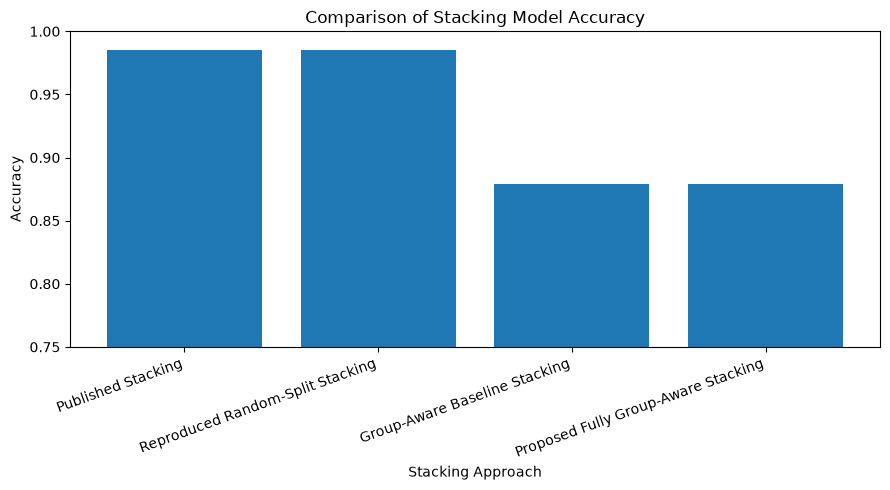

In [82]:
# Stacking accuracy comparison
accuracy_plot = part2_comparison[
    ["Model", "Accuracy"]
].copy()

plt.figure(figsize=(9, 5))

plt.bar(
    accuracy_plot["Model"],
    accuracy_plot["Accuracy"]
)

plt.ylabel("Accuracy")
plt.xlabel("Stacking Approach")
plt.title("Comparison of Stacking Model Accuracy")
plt.ylim(0.75, 1.0)

plt.xticks(
    rotation=20,
    ha="right"
)

plt.tight_layout()

plt.savefig(
    "../results/figures/part2_stacking_accuracy_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

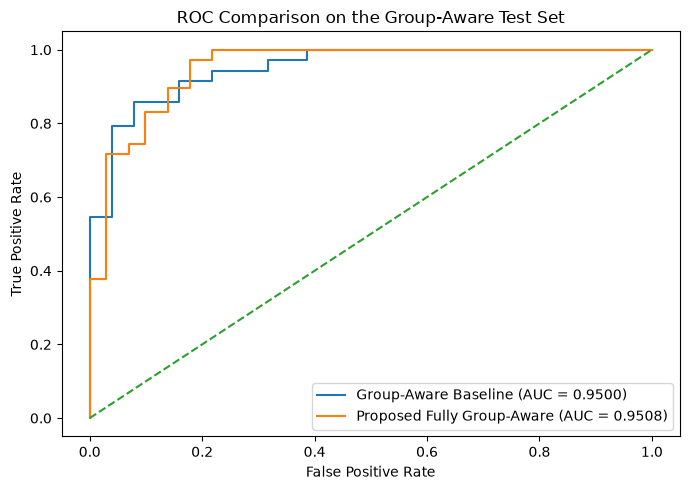

In [83]:
# ROC curve for the group-aware baseline
baseline_fpr, baseline_tpr, _ = roc_curve(
    y_outer_test,
    group_stack_prob
)

# ROC curve for the proposed method
proposed_fpr, proposed_tpr, _ = roc_curve(
    y_outer_test,
    proposed_prob
)

plt.figure(figsize=(7, 5))

plt.plot(
    baseline_fpr,
    baseline_tpr,
    label=(
        f"Group-Aware Baseline "
        f"(AUC = {group_stack_results['AUC']:.4f})"
    )
)

plt.plot(
    proposed_fpr,
    proposed_tpr,
    label=(
        f"Proposed Fully Group-Aware "
        f"(AUC = {proposed_results['AUC']:.4f})"
    )
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Comparison on the Group-Aware Test Set")
plt.legend()

plt.tight_layout()

plt.savefig(
    "../results/figures/part2_group_aware_roc_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

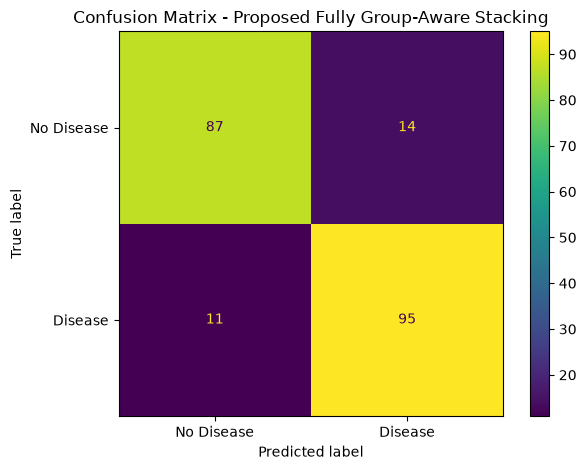

In [84]:
# Proposed model confusion matrix
proposed_cm = confusion_matrix(
    y_outer_test,
    proposed_pred
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=proposed_cm,
    display_labels=[
        "No Disease",
        "Disease"
    ]
)

disp.plot()

plt.title(
    "Confusion Matrix - Proposed Fully Group-Aware Stacking"
)

plt.tight_layout()

plt.savefig(
    "../results/figures/part2_proposed_confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### 7.6 Summary

The visual results support the findings from the numerical evaluation. The accuracy comparison shows a clear difference between the published and reproduced random-split results, which achieved approximately **98.5% accuracy**, and the two group-aware approaches, which both achieved **87.92% accuracy**. This highlights how strongly the validation strategy affects the estimated performance of the stacking model.

The ROC curves of the group-aware baseline and the proposed fully group-aware method are very similar because both models were evaluated on the same 207 held-out observations. The baseline achieved an AUC of **0.9500**, while the proposed method achieved a slightly higher AUC of **0.9508**. This indicates that extending duplicate-group separation into the internal stacking folds did not substantailly change the overall ability of the model to distinguish between the two classes.

The confusion matrix of the proposed model contains **87 true negatives, 95 true positives, 14 false positives, and 11 false negatives**. These results are consistent with the observed precision of **87.16%**, recall of **89.62%**, and specificity of **86.14%**.

Overall, the visual and numerical evidence shows that the main contribution of the proposed method is not an increase in headline accuracy, but a more rigorous evaluation procedure. By preventing identical feature groups from crossing both the external train-test split and the internal stacking folds, the proposed approach reduces the risk of information leakage and provides a more conservative estimate of performance on previously unseen feature patterns.

## 7.7 Critical Discussion and Limitations

The proposed duplicate-aware stacking framework was designed to address the main limittion identified during Part 1: repeated feature patterns appearing across different stages of model training and evaluation. The experimental results show that this methodological change can be implemented successfully without removing observations from the dataset. Duplicate groups were separated in both the outer train-test split and the internal stacking folds, meaning that the meta-classifier was trained using out-of-fold predictions generated without direct exposure to identical predictor combinations.

However, the proposed method did not improve overall accuracy compared with the simpler group-aware baseline. Both approaches achieved **87.92% accuracy** on the same held-out test set. The proposed method produced slightly higher precision (**87.16% compared with 85.84%**), specificity (**86.14% compared with 84.16%**), and AUC (**0.9508 compared with 0.9500**), but recall decreased from **91.51% to 89.62%**. Therefore, the results do not support a claim that the proposed method provides a major predictive-performance improvement.

Instead, its main contribution is increased experimental reliability. The standard group-aware baseline protected only the final train-test boundary, whereas the proposed aproach also protected the internal cross-validation process used to construct the stacking features. This reduces the opportunity for identical feature patterns to influence both the training and validation stages of the ensemble.

The substantial difference between the approximately **98.5% accuracy** obtained under the original random-split evaluation and the **87.92% accuracy** obtained under group-aware evaluation also demonstrates that model performance is highly sensitive to the validation strategy. The original paper reports very high performance for its stacking ensemble, but the present experiments suggest that evaluation on genuinely unseen feature patterns is more challenging. The paper itself describes stacking as a five-fold ensemble procedure in which a meta-classifier combines predictions from multiple base models. :chatgpt-content-reference{index="1"}

Several limitations remain in the proposed experiment. First, although the dataset contains 1,025 observations, only **302 unique predictor combinations** were identified. Retaining repeated rows preserves the original dataset size but does not increase the diversity of independent feature patterns available for learning.

Second, grouping was based on exact equality of the 13 predictor values. This prevents exact duplicate feature vectors from crossing validation boundaries, but it does not prevent highly similar or near-duplicate observations from appearing in different groups.

Third, the results are based on one group-aware outer split generated with `random_state=42`. A different group allocation could produce somewhat different performance. A stronger future study could use repeated group-aware cross-validation or nested group-based cross-validation to estimate the variability of the results across multiple folds and splits.

Fourth, the base classifiers were intentionaly kept at the same parameter settings used in the reproduction so that the effect of the redesigned validation procedure could be isolated. Consequently, the proposed method does not investigate whether hyper parameter optimisation, feature selection, alternative encoding strategies, or different meta-classifiers could further improve group-aware performance.

Finally, this study evaluates the model using a single publicly available heart disease dataset. Performance on this dataset does not by itself establish that the model would generalise to patients collected from different hospitals, populations, or clinical settings. External validation on an independent dataset would provide stronger evidence of real-world generalisation.

Overall, the proposed solution addresses the identified leakage risk and provides a more conservative evaluation of stacking performance. Although it does not improve accuracy over the simpler group-aware baseline, it strengthens the experimental protocol and demonstrates that the near-perfect random-split results should be interpreted cautiously. Future improvements should focus o increasing the number and diversity of independent patient records, evaluating performance across repeated group-aware splits, and optimising the models without compromising the leakage-resistant validation procedure.